# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Rivera, Kyle Florian
- _Student No._: 2024-16197
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Convergence plots of various root-finding methods](convergence.png)

Figure 1: Convergence plots of various root-finding methods.

### Report discussion

Figure 1 shows the convergence plots of various root-finding methods, more specifically, as the algorithm finds the root $x\approx 4.6$. As seen in Fig. 1a, the fixed-point algorithm converges the slowest out of the 4 methods, taking 50 iterations before finding the root. On the other hand, the Newton-Rhapson method converges the fastest, finding the root within 8 iterations.
Meanwhile, the bisection method zig-zags due from the repeated halving of the bracket, while the secant method zig-zags due to overshooting between the two guesses.

For both Newton-Rhapson and secant methods, we observe fast convergence (relative to bisection and fixed-point), but both can diverge or oscillate wildly depending on initial guesses. For bisection method, it guaranteed finding a root but it requires bracketing and knowing *around where* a root is, i.e. the funciton must cross zero. Finally, despite its slower convergence rate, fixed-point iteration remains valuable due to its simplicity and applicability in analyzing and solving systems of nonlinear equations.

### Other comments
- No comment, your honor.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

> Before we proceed, let us find the analytic derivative of f
> $$
\begin{align}
    f'(x) &= -5x^4 + 16x^3 - 12x^2 + x^2 e^x + 2xe^x - 4x - 4xe^x - 4e^x + 8 + 4e^x \\
          &= -5x^4 + 16x^3 - 12x^2 + x^2 e^x - 2xe^x - 4x + 8 
\end{align}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tolerance = 1e-8 # we set a tolerance that can be disguished from the machine precision

def f(x):
    return (-x**5) + (4*x**4) - (4*x**3) + (x**2*np.exp(x)) - (2*x**2) - (4*x*np.exp(x)) + (8*x) + (4*np.exp(x)) - 8 

def fp(x):
    return (-5*x**4) + (16*x**3) - (12*x**2) + (x**2 * np.exp(x)) - (2*x*np.exp(x)) - (4*x) + 8 

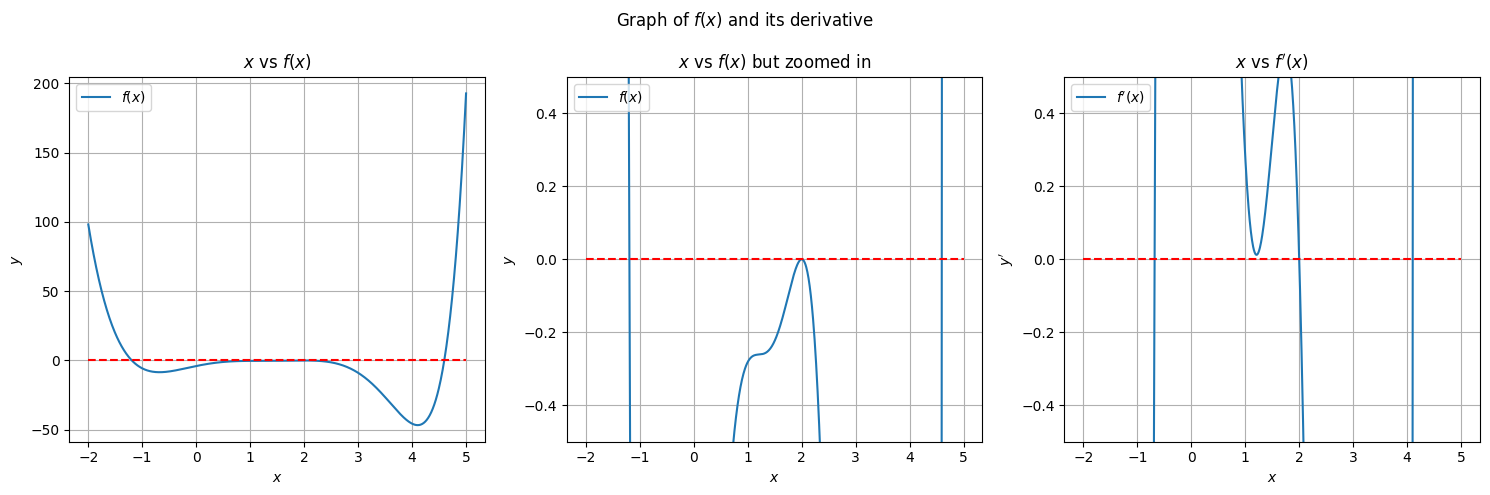

In [4]:
fig, [ax1, ax2, ax3] = plt.subplots(1,3,figsize=(15,5))

x = np.linspace(-2, 5, 1000)
y_0 = np.zeros(len(x))

# regular plot of x \in [-2,5]
ax1.plot(x, f(x), label='$f(x)$')
ax1.plot(x, y_0, color='red', ls='--')
ax1.legend(loc='upper left')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.grid(True)
ax1.set_title('$x$ vs $f(x)$')

# same plot but y axis is scaled
ax2.plot(x, f(x), label='$f(x)$')
ax2.plot(x, y_0, color='red', ls='--')
ax2.legend(loc='upper left')
ax2.set_ylim(-0.5,0.5)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.grid(True)
ax2.set_title('$x$ vs $f(x)$ but zoomed in')

# derivative of f(x)
ax3.plot(x, fp(x), label="$f'(x)$")
ax3.plot(x, y_0, color='red', ls='--')
ax3.legend(loc='upper left')
ax3.set_ylim(-0.5,0.5)
ax3.set_xlabel('$x$')
ax3.set_ylabel("$y'$")
ax3.grid(True)
ax3.set_title(r"$x$ vs $f'(x)$")

plt.suptitle("Graph of $f(x)$ and its derivative")

plt.tight_layout()
plt.show()

### Fixed Point:

We first rearrange $f(x)=0$ to the form $x = g(x)$.

$$
\begin{align}
    f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8 &= 0 \\
    -x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8 &= x^2 (2-e^x) \\
    \frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x} &= x^2 \\
    \sqrt{\frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x}} &= x
\end{align}
$$

It follows that
$$
g(x) = \sqrt{\frac{-x^5 + 4x^4 - 4x^3 -4xe^x + 8x + 4e^x -8}{2-e^x}}
$$

Note that we cannot find roots below $ln(2)$ as this falls outside the domain of $g(x)$

In [5]:
def g(x):
    return np.sqrt(((-x**5) + (4*x**4) - (4*x**3) - (4*x*np.exp(x)) + (8*x) + (4*np.exp(x)) - 8)/(2-np.exp(x)))
    
def fixed_point(function=f, x_0=2.5, k=100, tolerance=tolerance):
    x_guess = [x_0] # we put x_0 for plotting purposes 
    x_old = x_0
    print(f"Initial Guess: {x_old}")
    for i in range(1, k):
        x_new = function(x_old) # set the evaluated point as new point
        x_guess.append(x_new)
        x_diff = x_new - x_old
        if abs(x_diff/x_new) < tolerance: # we stop if the change is below the tolerance
            break
        x_old = x_new
    else:
        x_new = None # frees up the variable
        print(f"Root not found")

    return x_guess

Initial Guess: 1.7
Root not found
Final Result: 1.9991774124156805


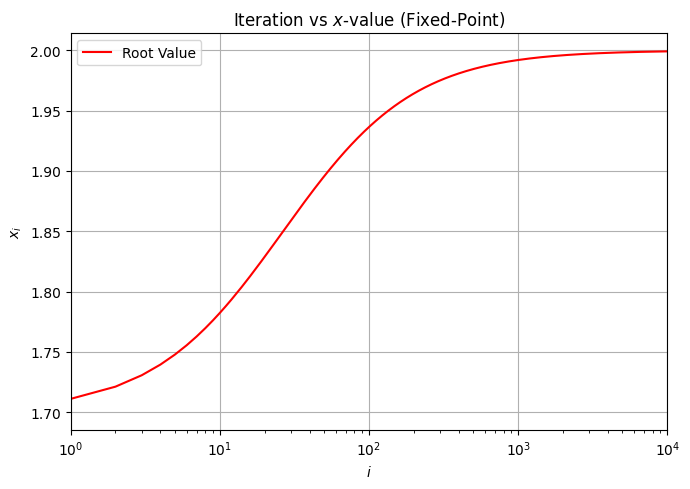

In [6]:
zeros = fixed_point(function=g, x_0=1.7, k=10000)
print(f"Final Result: {zeros[-1]}")

fig, ax1 = plt.subplots(figsize=(7,5))

x_fp = np.linspace(0, len(zeros)-1, len(zeros))
y_fp = zeros

ax1.semilogx(x_fp, y_fp, color='red', ls='-', label='Root Value')
ax1.legend()
ax1.set_xlabel('$i$')
ax1.set_ylabel('$x_i$')
ax1.set_xlim(1,x_fp[-1]+1)
ax1.grid(True)
ax1.set_title('Iteration vs $x$-value (Fixed-Point)')
plt.tight_layout()

We note that the convergence for fixed point is *so* slow. We reached the iteration limit (in this case $10,000$) without going below the tolerance we set.

### Bisection Method:

We first start with a boundary and determine whether the product between each boundary and the midpoint is negative.

In [7]:
def bisection_method(function=f, x_0=0, x_1=2, k=1000, tolerance=tolerance):
    f_0 = f(x_0)
    f_1 = f(x_1)
    x_guess = [(x_0 + x_1)/2]
    
    if f_0 * f_1 > 0: # we ensure that we only input opposite signs (by intermediate value theorem)
        raise ValueError(
            f"Root not bracketed on [{x_0}, {x_1}]: "
            f"f({x_0})={f_0} and f({x_1})={f_1} have the same sign."
        )
        
    print(f"Initial Boundary: [{x_0}, {x_1}]")
    for i in range(1, k):
        x_2 = (x_0 + x_1) / 2 # find the midpoint
        f_2 = f(x_2) # and evaluate the value of func in it
        x_guess.append(x_2)
        
        if abs(f_2) < tolerance or (x_1 - x_0)/2 < tolerance:
            break # if the function is less than the tolerance or the gap between midpoint

        if f_0 * f_2 < 0: # if the product is negative, we set the midpoint as the new boundary (replacing upper bound)
            x_1 = x_2
        else: # otherwise, replace lower bound
            x_0, f_0 = x_2, f_2


    else: 
        x_2_updated = None
        print(f"Root not found")
        return x_guess

    return x_guess

Initial Boundary: [-2, 0]
Root found at: -1.1926857605576515


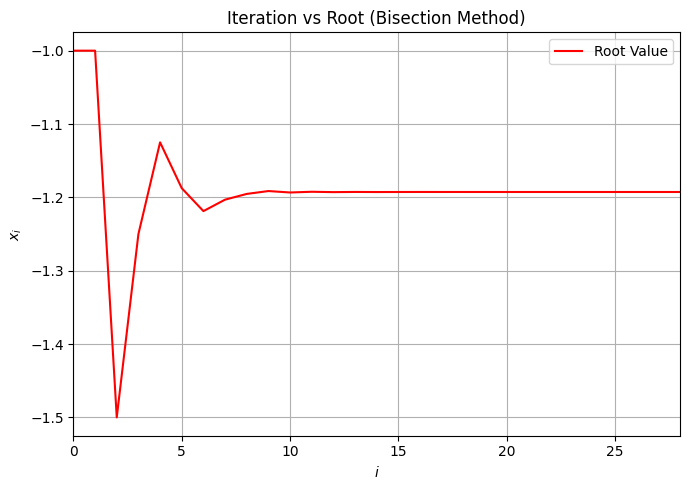

In [8]:
upper_bound = 0
lower_bound = -2
zeros = bisection_method(function=f, x_0=lower_bound, x_1=upper_bound, k=10000)
print(f"Root found at: {zeros[-1]}")

fig, ax1 = plt.subplots(figsize=(7,5))

x_bm = np.linspace(0, len(zeros)-1, len(zeros))
y_bm = zeros

ax1.plot(x_bm, y_bm, color='red', ls='-', label='Root Value')
ax1.legend()
ax1.set_xlabel('$i$')
ax1.set_ylabel('$x_i$')
ax1.set_xlim(0,len(zeros)-1)
ax1.grid(True)
ax1.set_title('Iteration vs Root (Bisection Method)')
plt.tight_layout()

### Newthon-Rhapson Method:

We already obtained the analytical derivative from earlier.

In [9]:
def newton_rhapson(function=f, derivative=fp, x_0=0, k=1000, tolerance=tolerance):
    zeros = [x_0]
    print(f"Initial Guess: {x_0}")
    x_diff = tolerance + 1
    x_i = x_0
    x_new = 1 # we just initialize these variables to be greater than the tolerance
    i = 1
    while abs(x_diff/x_new) > tolerance and i < k:
        x_new = x_i - f(x_i)/fp(x_i)
        x_diff = x_new - x_i
        zeros.append(x_new)
        x_i = x_new
        i += 1
    return zeros

Initial Guess: 1.7
Root found at: 1.9999999696605233


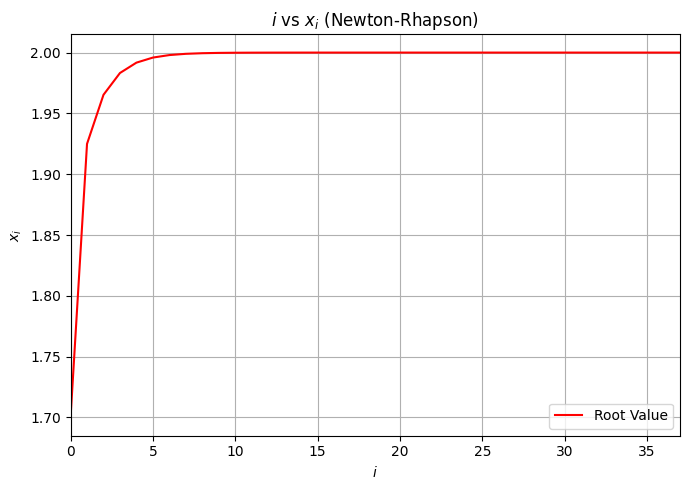

In [10]:
guess = 1.7
zeros = newton_rhapson(x_0 = guess)
print(f"Root found at: {zeros[-1]}")

fig, ax1 = plt.subplots(figsize=(7,5))

x_bm = np.linspace(0, len(zeros)-1, len(zeros))
y_bm = zeros

ax1.plot(x_bm, y_bm, color='red', ls='-', label='Root Value')
ax1.legend(loc='lower right')
ax1.set_xlabel('$i$')
ax1.set_ylabel('$x_i$')
ax1.set_xlim(0,len(zeros)-1)
ax1.grid(True)
ax1.set_title('$i$ vs $x_i$ (Newton-Rhapson)')
plt.tight_layout()

### Secant Method:

We can simply modify the Newton-Rhapson method and adjust for a second input.

In [11]:
def secant(function=f, x_0=0, x_1=1, k=1000, tolerance=tolerance):
    print(f"Initial Guess: x_0={x_0}, x_1={x_1}")   
    zeros = [x_0, x_1]
    x_diff = tolerance + 1
    x_new = 1 # we just initialize these variables to be greater than the tolerance
    i = 1
    while abs(x_diff/x_new) > tolerance and i < k:
        x_new = x_1 - f(x_1) * ( (x_1 - x_0) / (f(x_1) - f(x_0)) )
        x_diff = x_new - x_1
        zeros.append(x_new)
        x_0, x_1 = x_1, x_new
        i += 1
    return zeros

Initial Guess: x_0=4.67, x_1=5.67
Root found at: 4.595863564922464


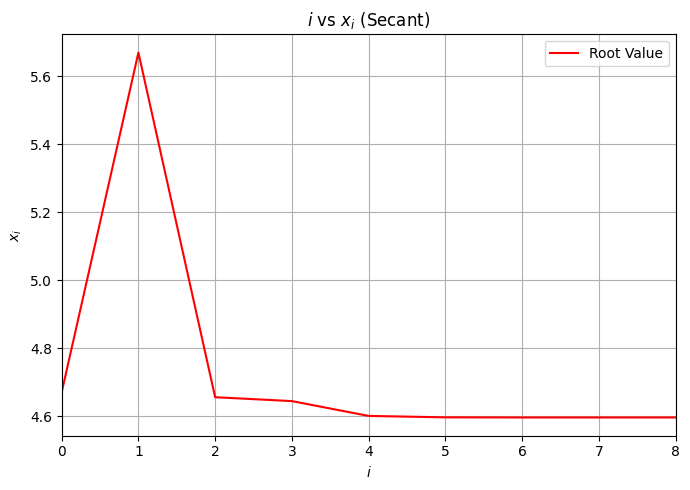

In [12]:
zeros = secant(x_0 = 4.67, x_1 = 5.67)
print(f"Root found at: {zeros[-1]}")

fig, ax1 = plt.subplots(figsize=(7,5))

x_bm = np.linspace(0, len(zeros)-1, len(zeros))
y_bm = zeros

ax1.plot(x_bm, y_bm, color='red', ls='-', label='Root Value')
ax1.legend(loc='upper right')
ax1.set_xlabel('$i$')
ax1.set_ylabel('$x_i$')
ax1.set_xlim(0,len(zeros)-1)
ax1.grid(True)
ax1.set_title('$i$ vs $x_i$ (Secant)')
plt.tight_layout()

### Root $x\approx 4.6$:

Let us plot the convergence plot for methods of which we found the root $x\approx 4.6$.

Initial Guess: 6
Initial Boundary: [4, 5]
Initial Guess: 6
Initial Guess: x_0=4, x_1=5


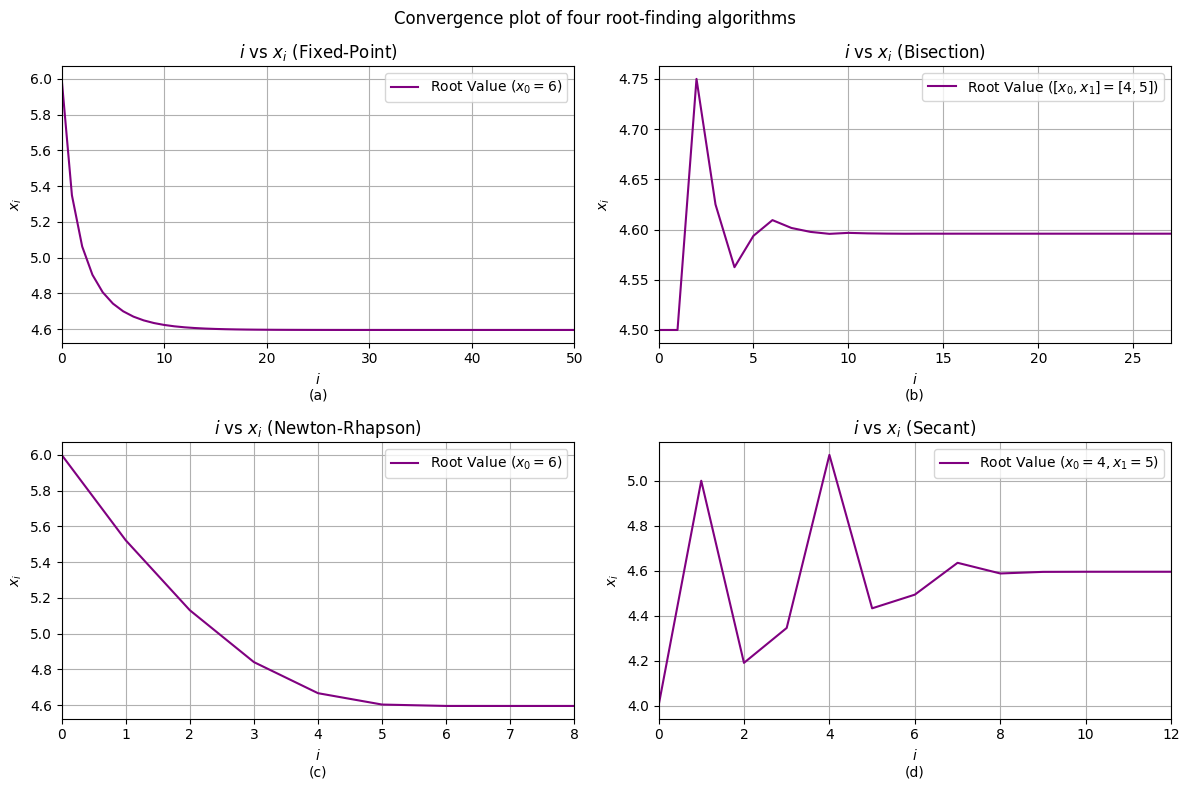

In [13]:
zero_f = fixed_point(function=g, x_0=6, k=100000)
zero_b = bisection_method(function=f, x_0=4, x_1=5)
zero_n = newton_rhapson(x_0 = 6)
zero_s = secant(x_0 = 4, x_1 = 5)

zeros = [zero_f, zero_b, zero_n, zero_s]
title = ["Fixed-Point", "Bisection", "Newton-Rhapson", "Secant"]
guesses = ["$x_0 = 6$", "$[x_0, x_1] = [4, 5]$", "$x_0 = 6$", "$x_0 = 4, x_1 = 5$"]
labels = ["(a)", "(b)", "(c)", "(d)"]

fig, axs = plt.subplots(2, 2, figsize=(12,8))

for root, name, guess, label, ax in zip(zeros, title, guesses, labels, axs.flat):
    x = np.arange(len(root))
    y = root
    
    ax.plot(x, y, color='purple', ls='-', label=f'Root Value ({guess})')
    ax.set_xlim(0, max(len(root) - 1, 1))
    ax.set_xlabel(f'$i$\n{label}')
    ax.set_ylabel('$x_i$')
    ax.set_title(f'$i$ vs $x_i$ ({name})')
    ax.legend()
    ax.grid(True)

plt.suptitle("Convergence plot of four root-finding algorithms")
plt.tight_layout()
plt.savefig("convergence.png")
plt.show()

#### Problem 1 code summary


Since all four methods of root finding are iterative, the code was implemented with the use of for and while loops. For all methods, the algorithm was iterated until a root was found, (which is determined by when the change is smaller than the tolerance) or when the maximum number of iterations has been reached. For methods with slow convergence, a high iteration limit and a logarithmic plot was used in order to visualize the rate of convergence.

---